# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

In [ ]:
max_depth 파라미터 값이 커지면 노드가 그만큼 늘어나게 되어 데이터를 세부적으로 학습한다.
따라서 '노이즈',' 이상치' 역시 학습할 위험이 커지며 과적합의 위험이 발생할 수 있다.

반면, max_depth 파라미터 값이 작아지면 노드가 줄어들어 과소적합의 위험이 발생할 수 있다.

In [3]:
# 결정 트리 모델 생성 및 학습
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)

### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

gini index는 데이터의 불순도를 뜻하며, 0~0.5의 값을 가진다.
데이터가 완벽하게 한 클래스로 이루어져 있을 때 불순도 값이 0이 되며,
그와 반대로 데이터가 완벽히 나누어져 있을 때 불순도 값이 최대(0.5)가 된다.

entropy는 데이터의 무질서도를 뜻하며, 0~1의 값을 가진다.
데이터가 완벽하게 한 클래스로 이루어져 있을 때 무질서도 값이 0이 되며,
그와 반대로 데이터가 완벽히 나누어져 있을 때 무질서도 값이 최대(1)가 된다.

gini의 계산 속도가 entropy보다 빠르며
gini index의 경우 한쪽 가지로 가장 빈도가 높은 클래스를 먼저 고립시키는 경향이 있다.
반면, entropy의 경우 트리의 구조를 좀 더 좌우 대칭으로 균형 있게 나누는 경향이 있다.


### Q1.3 각 노드의 분할 기준 어떻게 되는지 설명해보세요.

In [4]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

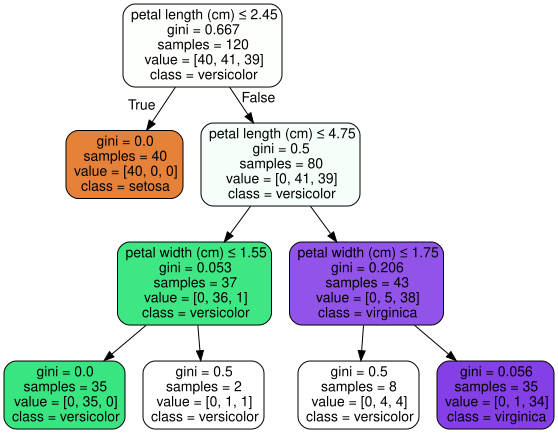

In [5]:
# 그래프 출력
graph = graphviz.Source(dot_data)
graph

- 첫 번째  노드: petal length(cm)가 2.45 이하인지
- 두 번째 노드: petal length(cm)가 4.75 이하인지
- 세 번째 노드: petal width(cm)가 1.55 이하인지 / petal width(cm)가 1.75 이하인지

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [6]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [7]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [8]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [9]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)

print(f"Random Forest MSE: {rf_mse:.4f}")

Random Forest MSE: 0.2554


### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [16]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(random_state=42)
ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)
ada_mse = mean_squared_error(y_test, ada_pred)

print(f"AdaBoost MSE: {ada_mse:.4f}")

AdaBoost MSE: 0.6145


### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)

print(f"Gradient Boosting MSE: {gb_mse:.4f}")

Gradient Boosting MSE: 0.2940


### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [20]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'mse',
    'learning_rate': 0.05,
    'max_depth': 5,
    'seed': 42,
    'verbose': -1               #
}

lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test']
)

lgb_pred = lgb_model.predict(X_test)
lgb_mse = mean_squared_error(y_test, lgb_pred)

print(f"\nLightGBM MSE: {lgb_mse:.4f}")


LightGBM MSE: 0.2381


### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [21]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'seed': 42
}


evals = [(dtrain, 'train'), (dtest, 'test')]

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=evals,
    verbose_eval=False
)

xgb_pred = xgb_model.predict(dtest)
xgb_mse = mean_squared_error(y_test, xgb_pred)

print(f"\nXGBoost MSE: {xgb_mse:.4f}")


XGBoost MSE: 0.2366


### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

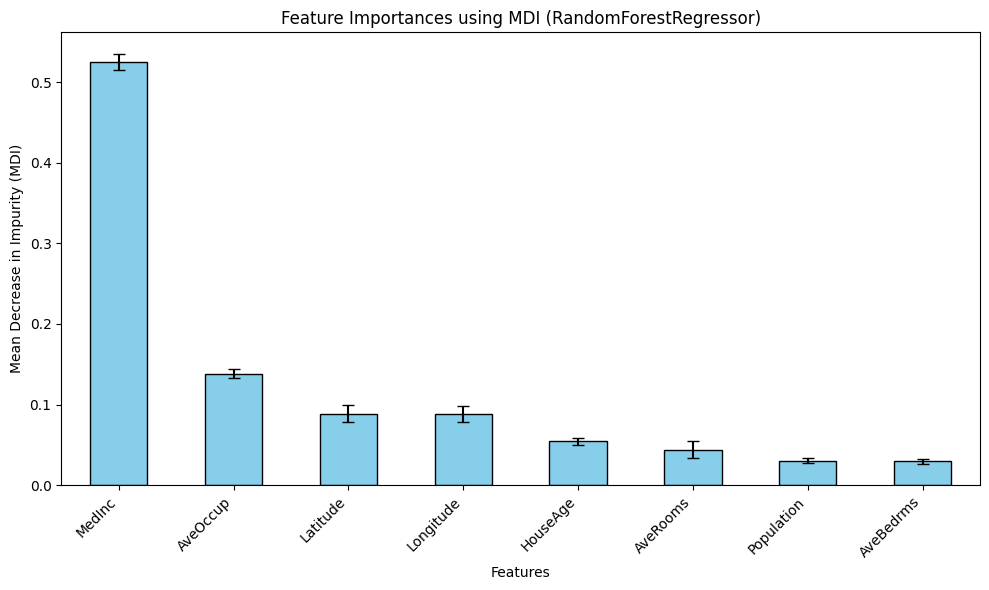

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

importances = rf_model.feature_importances_

std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

forest_importances_df = pd.DataFrame({
    'importance': importances,
    'std': std
}, index=X_train.columns)

forest_importances_df = forest_importances_df.sort_values(by='importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances_df['importance'].plot.bar(
    yerr=forest_importances_df['std'],
    ax=ax,
    capsize=4,
    color='skyblue',
    edgecolor='black'
)

ax.set_title("Feature Importances using MDI (RandomForestRegressor)")
ax.set_ylabel("Mean Decrease in Impurity (MDI)")
ax.set_xlabel("Features")

plt.xticks(rotation=45, ha='right')
fig.tight_layout()

plt.show()

### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보세요.

### 💡 Boosting 모델 특징 비교

| 모델명 | 핵심 학습 원리 (트리 생성 방식) | 장점 | 단점 및 주의점 | 학습 속도 |
| :--- | :--- | :--- | :--- | :--- |
| **AdaBoost** | 이전 트리가 **오분류한 데이터에 가중치**를 부여하여 다음 트리가 학습 | • 구조가 직관적이고 단순함<br>• 과적합에 비교적 강함 | • 이상치나 노이즈 데이터에 매우 민감함<br>• 복잡한 데이터에서는 성능이 다소 떨어짐 | 보통 |
| **Gradient Boosting (GBM)** | 이전 트리의 **잔차**를 줄이는 방향으로 새로운 트리를 학습 | • 예측 성능(정확도)이 매우 뛰어남 | • 순차적으로 학습하여 병렬 처리 불가<br>• 과적합 방지(규제) 기능이 부족함 | **가장 느림** |
| **XGBoost** | GBM을 기반으로 하되, 시스템적 최적화와 **정규화** 추가 | • L1, L2 규제로 과적합 방지 탁월<br>• 결측치 자체 처리 기능 제공<br>• 조기 종료(Early stopping) 지원 | • 하이퍼파라미터가 너무 많아 튜닝이 까다로움<br>• LightGBM에 비해 메모리 사용량이 많음 | 빠름 |
| **LightGBM** | 비대칭적인 **리프 중심 트리 분할** 및 히스토그램 기반 알고리즘 사용 | • 대용량 데이터 처리에 최적화됨<br>• 메모리 사용량이 적음<br>• XGBoost와 대등한 성능 | • 적은 데이터(약 1만 건 이하)에서는 **과적합 발생 위험이 큼**<br>• `max_depth` 조절이 필수적임 | **가장 빠름** |

### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.

1. 데이터셋에서 변수들을 가공해 파생변수를 만들어 학습시킨다.
2. 앙상블 모델의 경우 GridSearchCV나 RandomizedSearchCV를 이용하여 최적의 파라미터를 찾기 위해 노력한다.
3. K-fold 교차검증을 통해 정확도를 높인다.